Clase 5 Foro Obligatorio

Consigna: deberás elegir 2 modelos de clasificación de los vistos en el bloque y utilizando un dataset de tu interés aplicar ambos modelos para resolver un problema de aprendizaje automático. Deberás entregar la notebook en tu repositorio y además un video deno más de 10 minutos donde expliques cómo cada modelo elegido resuelve el problema, qué evaluación podemos hacer de cada modelo y en conclusión cuál modelo considerás que aborda mejor el problema.

Elijo los modelos Arbol de descisión y SVM, y de Kaggle tomo el dataset para predicción de Infartos.

Tomo el esquema del código de la clase 5 y el dataset de predicción de infartos, donde comparo el funcionamiento y resultados de los modelos KNN y arbol de decisión, y lo modifico para que ahora comparemos el funcionamiento de arbol de decisión y svm.

Dataset
Stroke Prediction Dataset
11 clinical features for predicting stroke events

Context
According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

Attribute Information
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient


Variables seleccionadas:
Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level'], dtype='object')

Mejores hiperparámetros Arbol de Decisión:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor score:
0.9585704413924161

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

  No Infarto       0.99      0.59      0.74      1458
     Infarto       0.10      0.87      0.17        75

    accuracy                           0.60      1533
   macro avg       0.54      0.73      0.46      1533
weighted avg       0.94      0.60      0.71      1533



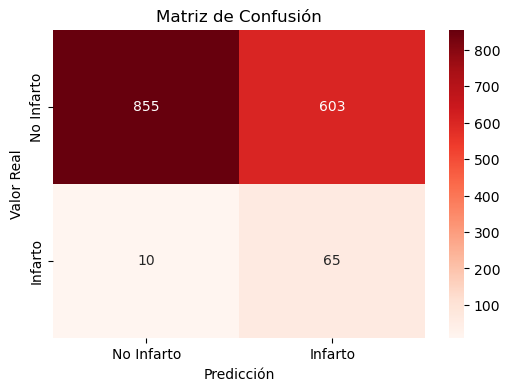


Importancia de Variables Arbol de decisión:
            Variable  Importancia
0                age          1.0
1       hypertension          0.0
2      heart_disease          0.0
3  avg_glucose_level          0.0


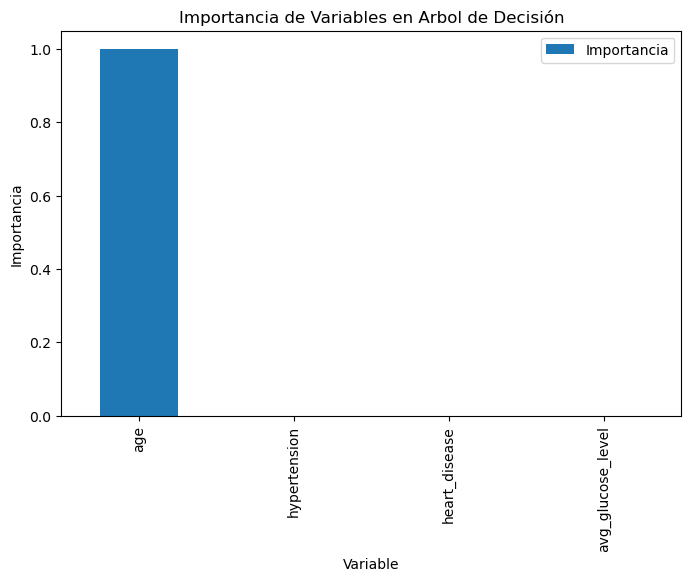

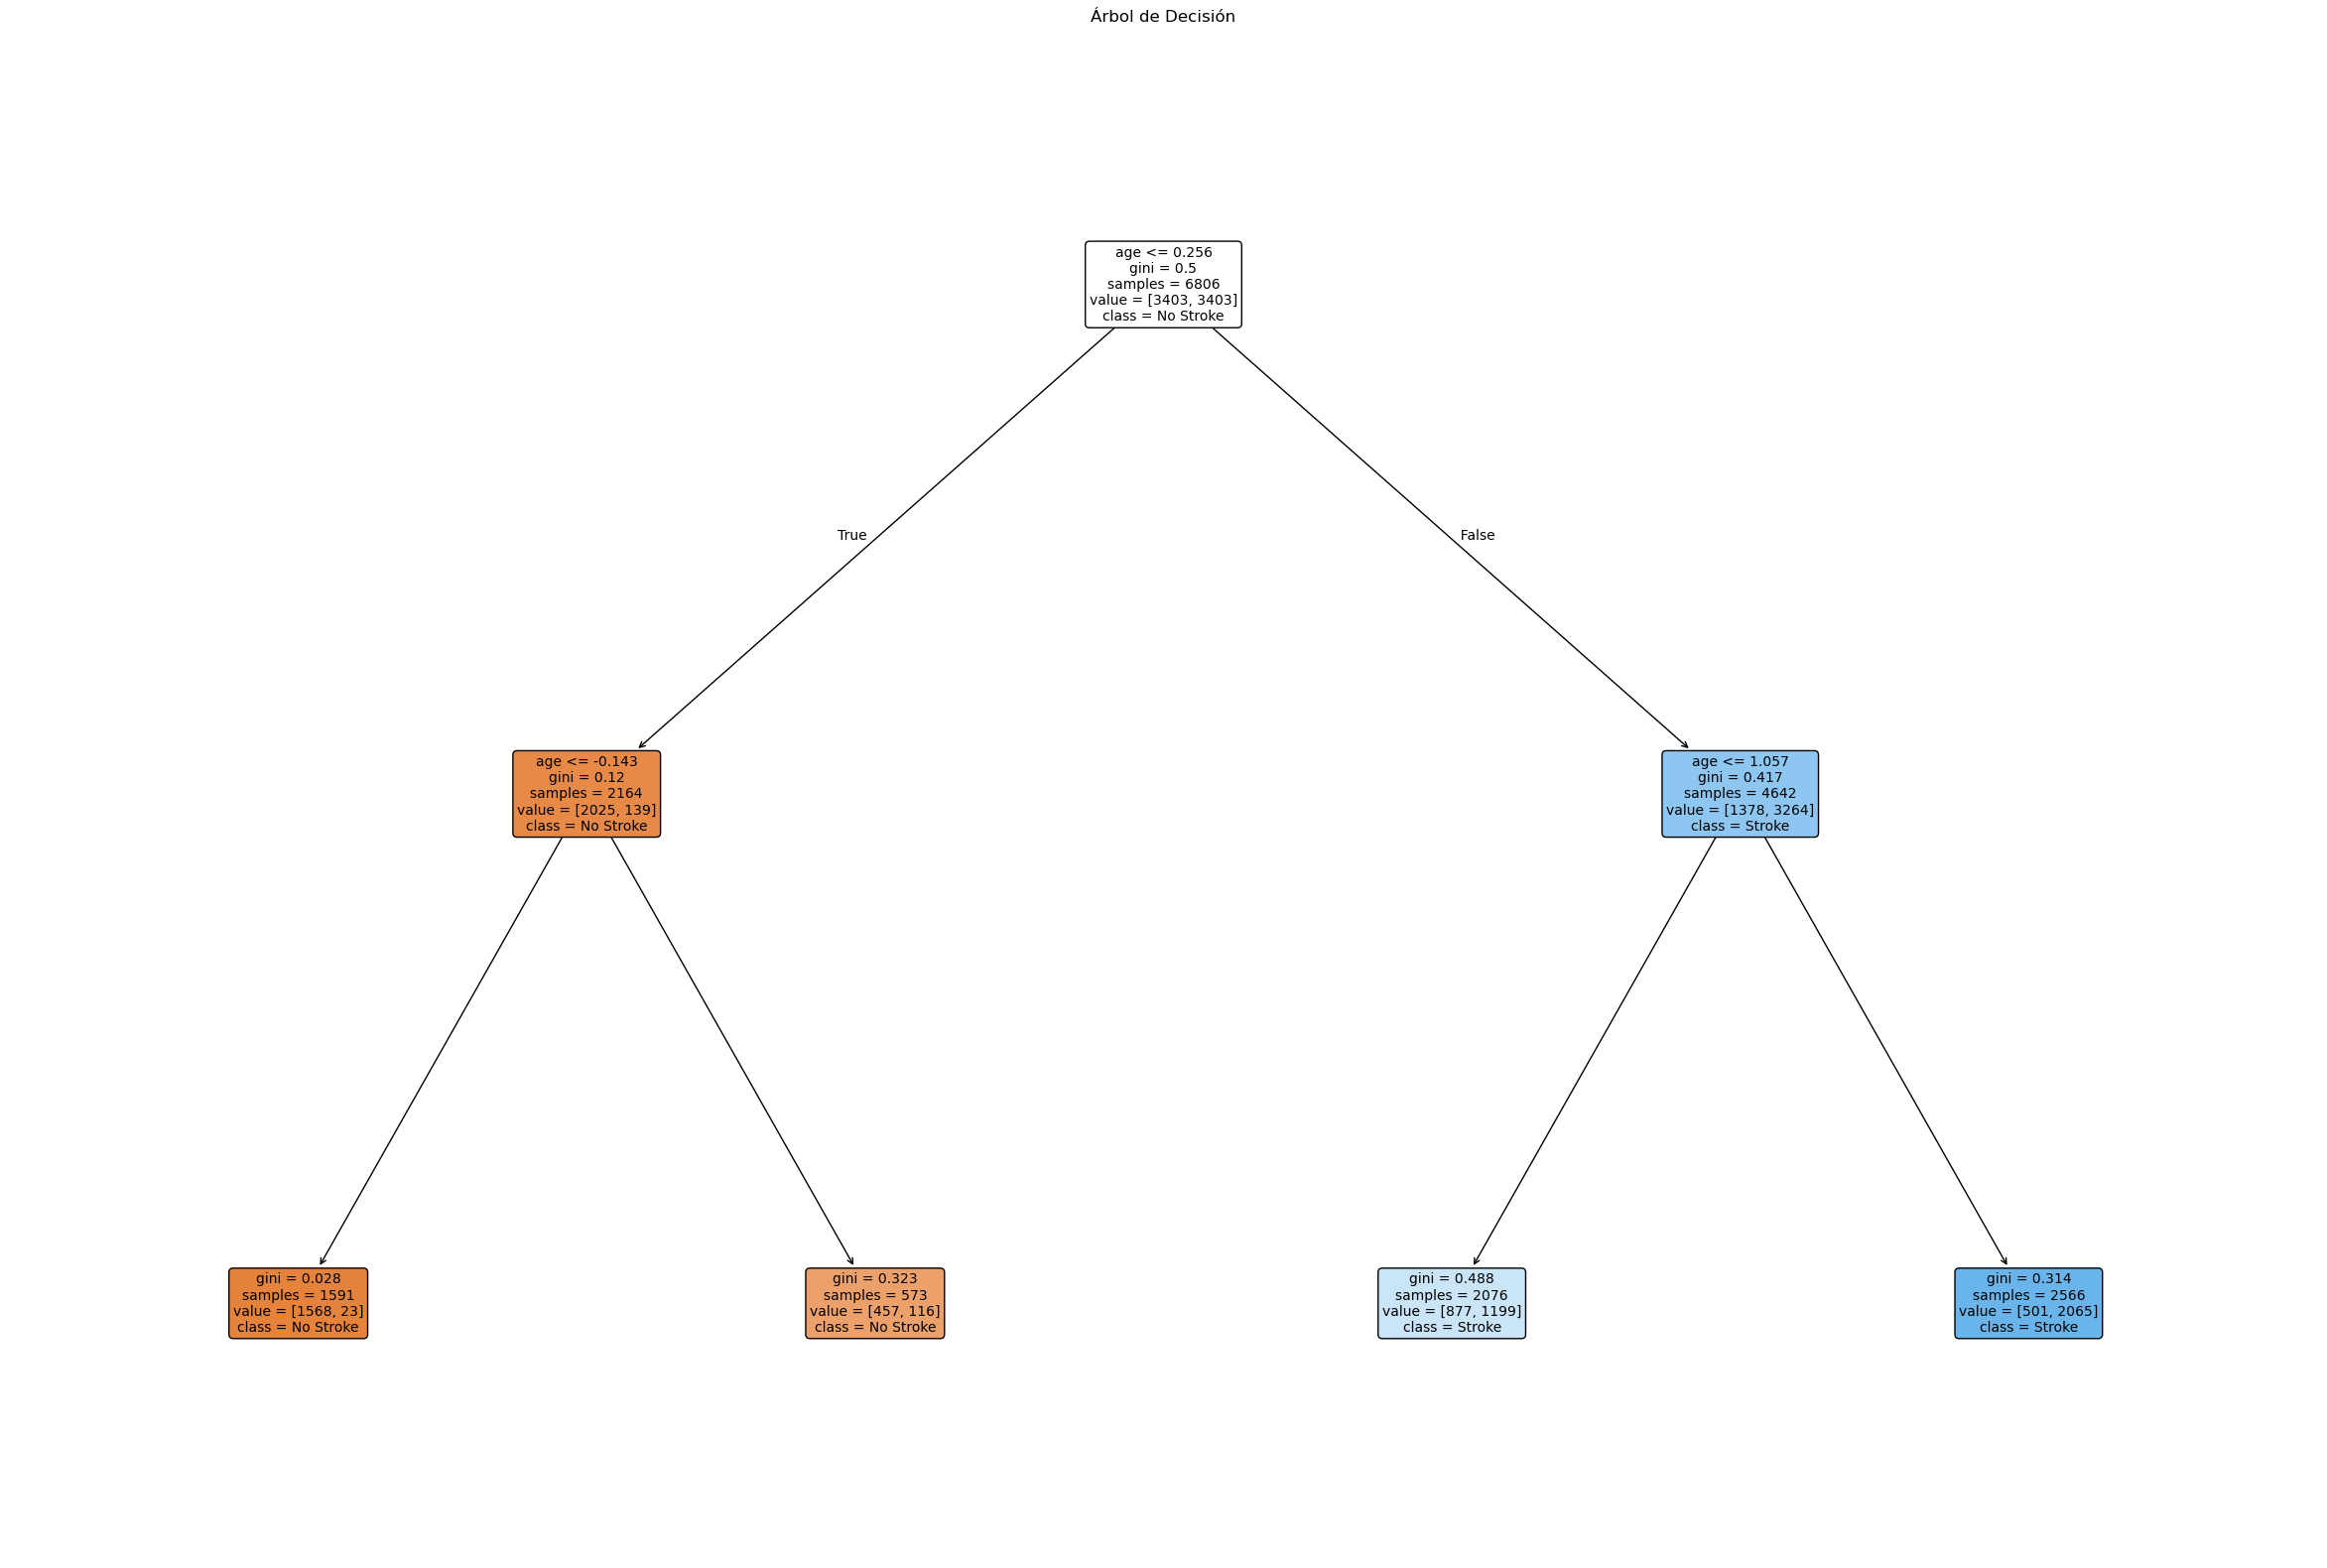


Mejores hiperparámetros SVM:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Mejor score:
0.8883303100976073

Métricas SVM:
              precision    recall  f1-score   support

  No Infarto       0.99      0.69      0.81      1458
     Infarto       0.12      0.83      0.21        75

    accuracy                           0.70      1533
   macro avg       0.55      0.76      0.51      1533
weighted avg       0.94      0.70      0.78      1533



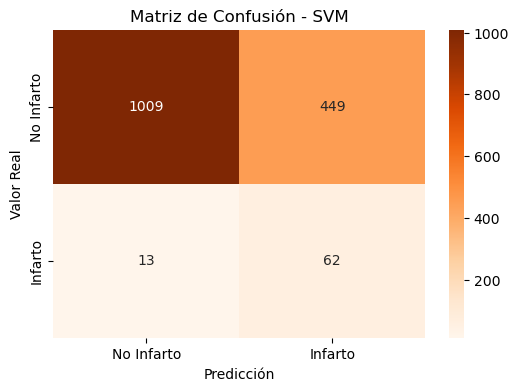


Importancia de Variables SVM:
            Variable  Importancia
0                age     0.044749
3  avg_glucose_level     0.004371
1       hypertension     0.003196
2      heart_disease    -0.000913


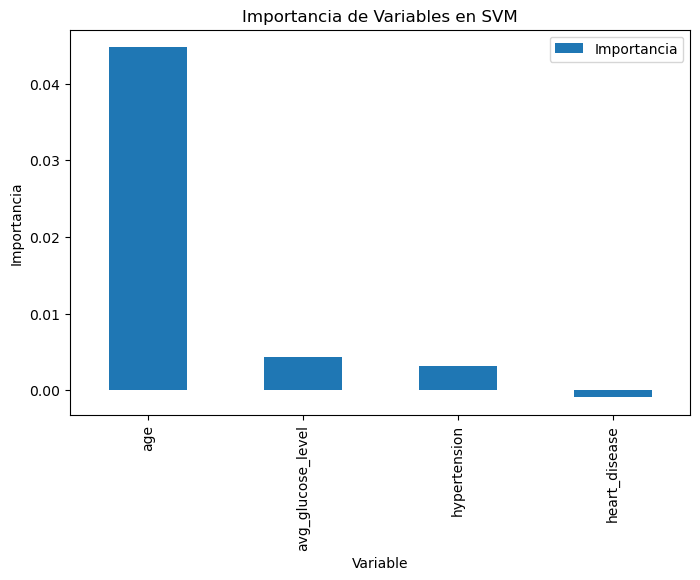

In [7]:

# importación de librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import plot_tree

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.inspection import permutation_importance

# Importación de Archivo CSV (Comma-Separated Values)

datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 5\healthcare-dataset-stroke-data.csv", encoding= "ISO-8859-1")

# Preparación de X e y

X = datos_csv.drop("stroke", axis=1)
y = datos_csv["stroke"]

# En la instancia original identificamos que bmi tenía registros NaN.
# Reemplazamos los NaN con la mediana. Por lo que leí es lo más conveniente para no perder registros.

imputer = SimpleImputer(strategy="median")
X[["bmi"]] = imputer.fit_transform(X[["bmi"]])

# Vamos a convertir las variables categóricas del dataset original en columnas binarias.
# Se podrían convertir en codificación por etiquetas (1,2,3,...) pero el modelo podría asumir que alguna es mayor que otra.
# Lo que es cierto es que aumenta la cantidad de dimensiones del dataset original
# Voy a dejar el drop_first en False para que no perdamos datos, aún no sabemos qué variables vamos a seleccionar

X = pd.get_dummies(X,drop_first=False)

# Ahora el conjunto de datos está listo!

# Vamos a usar SelectKBest para ver las variables más relevantes.

selector = SelectKBest(score_func=f_classif,k=4)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Variables seleccionadas:")
print(selected_features)

# División de entrenamiento y prueba
# stratify=y para mantener la misma proporción de clases que el dataset original

X_train, X_test, y_train, y_test = train_test_split(X_selected,y,test_size=0.3,random_state=42,stratify=y)

# Vamos a escalar los datos
# Es importante para el modelo SVM, y no sería necesario para el Arbol de Decisión.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vamos a aplicar el SMOTE para generar datos sintéticos para contrarrestar el desbalanceo.
# Se hace solo al conjunto de entrenamiento, no al test.

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled,y_train)

# Modelo Arbol de Decisión
# -----------------------------------------------------------------------------------------------

# Vamos a buscar los mejores hiperparámetros para el modelo de Arbol de Decisión con GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2,11),
    'min_samples_split': range(2,11),
    'min_samples_leaf': range(1,6)
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_tree.fit(
    X_train_resampled,
    y_train_resampled
)

# Los mejores hiperparametros para el Arbol de decisión son los siguientes:

print("\nMejores hiperparámetros Arbol de Decisión:")
print(grid_tree.best_params_)

print("\nMejor score:")
print(grid_tree.best_score_)

# Cargamos los mejores parametros

best_tree = grid_tree.best_estimator_

# Ejecutamos el modelo con los mejores parametros

y_pred = best_tree.predict(X_test_scaled)

# Vemos las métricas del Arbol de Decisión

print("\nMétricas Árbol de Decisión:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Infarto",
            "Infarto"
        ],
        zero_division=0
    )
)

# Matriz de confusión del Arbol de decisión

cm_AdD = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm_AdD,annot=True,fmt="d",cmap="Reds",xticklabels=["No Infarto","Infarto"], yticklabels=["No Infarto","Infarto"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")

plt.show()

# Mostramos la relevancia de las variables en la definición del Arbol de Decisión

importance_AdD = pd.DataFrame({'Variable': selected_features,'Importancia': best_tree.feature_importances_})

importance_AdD = importance_AdD.sort_values(by='Importancia',ascending=False)

print("\nImportancia de Variables Arbol de decisión:")
print(importance_AdD)

# Graficamos

importance_AdD.plot(
    x='Variable',
    y='Importancia',
    kind='bar',
    figsize=(8,5)
)

plt.title("Importancia de Variables en Arbol de Decisión")
plt.ylabel("Importancia")

plt.show()

# Vamos a mostrar el Arbol de decisión
# Nuestro código escala los valores para poder preprocesar los datos una sola vez
# Al mostrar el arbol, se ven los datos escalados
# Para la próxima deberiamos separar el preproceso de los datos para el Arbol de Decisión

plt.figure(figsize=(30,20))

plot_tree(
    best_tree,
    feature_names=selected_features,
    class_names=["No Stroke", "Stroke"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión")

plt.show()


# Modelo SVM
# -----------------------------------------------------------------------------------------------

# Vamos a buscar los mejores hiperparámetros para el modelo de SVM con GridSearchCV
# En un archivo paralelo probamos con todos los kernel, linear, polynomial, sigmoid y rbf,
# El que mejores resultados nos brindó fue rbf

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(
        class_weight='balanced'
    ),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_svm.fit(
    X_train_resampled,
    y_train_resampled
)


# Los mejores hiperparametros para SVM son los siguientes:

print("\nMejores hiperparámetros SVM:")
print(grid_svm.best_params_)

print("\nMejor score:")
print(grid_svm.best_score_)

# Cargamos los mejores parametros

best_svm = grid_svm.best_estimator_

# Ejecutamos el modelo con los mejores parametros

y_pred = best_svm.predict(X_test_scaled)

# Vemos las métricas de SVM

print("\nMétricas SVM:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Infarto",
            "Infarto"
        ],
        zero_division=0
    )
)

# Matriz de confusión de SVM

cm_svm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm_svm,annot=True,fmt="d",cmap="Oranges",xticklabels=["No Infarto","Infarto"],yticklabels=["No Infarto","Infarto"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - SVM")

plt.show()

# Mostramos la relevancia de las variables en la definición de SVM
# SVM por rbf no permite evaluar la importancia de las variables desde el modelo, hay que hacerlo externamente

result = permutation_importance(
    best_svm,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_svm = pd.DataFrame({
    'Variable': selected_features,
    'Importancia': result.importances_mean
})

importance_svm = importance_svm.sort_values(
    by='Importancia',
    ascending=False
)

print("\nImportancia de Variables SVM:")
print(importance_svm)

# Graficamos

importance_svm.plot(
    x='Variable',
    y='Importancia',
    kind='bar',
    figsize=(8,5)
)

plt.title("Importancia de Variables en SVM")
plt.ylabel("Importancia")

plt.show()

